# Data augmentation

### An augmentation is a claim about your labels, and a false claim trains on wrong ones

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | When augmentation pays and when it does nothing, measured against training set size; what a wrong augmentation costs; how to write one by hand on the array; what it costs in seconds per epoch; and whether augmenting at test time is worth the extra passes |
| **You should already know** | [08-02 A convolutional network, layer by layer](../02-a-cnn-layer-by-layer/) |
| **Dataset** | Fashion-MNIST, in nested subsets from a few hundred images up to a few thousand |
| **Runtime** | Three to five minutes on a laptop CPU. The device it used is printed below |
| **Next** | [08-05 Transfer learning](../05-transfer-learning/) |

---

## 1. The idea

You have a thousand photographs and a model that wants a hundred thousand. Data
augmentation makes more training examples out of the ones you have by changing
each image in ways that do not change what it is. Shift a boot two pixels left
and it is still a boot, so the pair (shifted image, "boot") is a legitimate
training example that you did not have to collect.

That sentence hides the whole subject. **"in ways that do not change what it
is"** is a claim about your labels, and nothing in the code checks it. When you
add a random horizontal flip you are asserting that mirrored garments carry the
same label. When you add a rotation you are asserting that a tilted sandal is
still a sandal. Assert something false and you have quietly built a training set
with wrong labels in it, and the model will do exactly what you asked.

So this chapter is not a catalogue of transforms. The library has thirty of them
and the documentation lists them better than I could. It is three measurements:

1. How the payoff changes as the training set grows. I expect augmentation to
   matter most when data is scarce and to fade as it stops being scarce, so the
   sweep below tests exactly that and the printed verdict says which way it went.
2. What a label-destroying augmentation costs, using one that is obviously wrong
   for this dataset so the damage is unambiguous.
3. What it costs in wall-clock time, because generating images on the fly is not
   free and the bill lands on every epoch.

Then a fourth question at the end: if augmenting the training set helps, does
augmenting the test set help too.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
import torchvision.transforms.functional as TF

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"

SIZES = [250, 500, 1000, 2000, 4000]   # nested training subsets
BATCH = 128
STEPS = 250            # gradient steps per run, the same for every size
LR = 1e-3

CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]

NOTEBOOK_STARTED = time.perf_counter()
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


### The data, and why the subsets are nested

Every training set below is a prefix of the same shuffled pool, so the 250-image
run trains on a subset of what the 4,000-image run trains on. Drawing a fresh
random subset at each size would add a second moving part, and the sweep would
then be measuring subset luck as well as subset size.

In [2]:
def as_tensors(dataset, n=None, seed=SEED):
    """Materialise a dataset, or a random subset of it, as one (images, labels) pair."""
    labels = dataset.targets
    if n is None:
        keep = torch.arange(len(labels))
    else:
        keep = torch.randperm(len(labels), generator=torch.Generator().manual_seed(seed))[:n]
    images = dataset.data[keep].unsqueeze(1).float().div_(255.0)
    return images, labels[keep].clone()


x_pool, y_pool = as_tensors(datasets.fashion_mnist(train=True), max(SIZES))
x_test, y_test = as_tensors(datasets.fashion_mnist(train=False))

print(f"training pool : {len(y_pool):,} images, subsets {SIZES}")
print(f"test set      : {len(y_test):,} images, used whole for every score below")
print(f"pixel range   : {x_pool.min():.1f} to {x_pool.max():.1f}")
print(f"class counts in the smallest subset: "
      f"{torch.bincount(y_pool[:min(SIZES)], minlength=10).tolist()}")

training pool : 4,000 images, subsets [250, 500, 1000, 2000, 4000]
test set      : 10,000 images, used whole for every score below
pixel range   : 0.0 to 1.0
class counts in the smallest subset: [30, 21, 26, 19, 27, 19, 26, 27, 24, 31]


## 2. The maths, such as it is

Ordinary training minimises the loss averaged over the examples you have:

$$\hat{R}(f) = \frac{1}{n}\sum_{i=1}^{n} \ell\big(f(x_i),\, y_i\big)$$

Augmentation replaces each example by an average over a distribution
$\mathcal{T}$ of transformations:

$$\hat{R}_{\text{aug}}(f) = \frac{1}{n}\sum_{i=1}^{n}
  \mathbb{E}_{t \sim \mathcal{T}}\Big[\ell\big(f(t(x_i)),\, y_i\big)\Big]$$

Look at what moved and what did not. The input went through $t$. The label did
not. So the objective assumes

$$y\big(t(x)\big) = y(x) \quad \text{for every } t \in \mathcal{T}$$

which is the invariance claim written down. Where it holds, you have manufactured
training data for free and pushed the model towards a function that ignores $t$.
Where it fails, the term $\ell(f(t(x_i)), y_i)$ is a labelled example whose label
is wrong, and gradient descent will fit it as diligently as it fits the real ones.

There is no free lunch hiding here. Augmentation adds no information; it encodes
a prior you already held. The gain comes from spending model capacity on the
variation you care about instead of on variation you have decided is irrelevant.
That is why the payoff should shrink as real data arrives: with enough examples
the model can learn the invariance from the data, and your prior stops being the
scarce resource.

## 3. From scratch: one augmentation on the array

Translation, written out. Four lines of slicing, no library involved. The
convention is that positive `dx` moves the content right and positive `dy` moves
it down, and the space left behind is filled with zeros, which for
Fashion-MNIST is background.

In [3]:
def shift_image(image, dx, dy):
    """Translate a 2-D array by (dx, dy) pixels. Vacated pixels become zero."""
    out = np.zeros_like(image)
    height, width = image.shape
    src_x = slice(max(0, -dx), width - max(0, dx))
    dst_x = slice(max(0, dx), width - max(0, -dx))
    src_y = slice(max(0, -dy), height - max(0, dy))
    dst_y = slice(max(0, dy), height - max(0, -dy))
    out[dst_y, dst_x] = image[src_y, src_x]
    return out


def shift_batch(images, dx, dy):
    """The same translation applied to a whole (N, 1, H, W) batch in one call."""
    padded = F.pad(images, (abs(dx), abs(dx), abs(dy), abs(dy)))
    top, left = abs(dy) - dy, abs(dx) - dx
    return padded[:, :, top:top + images.shape[2], left:left + images.shape[3]]


# The check that matters: does my slicing agree with the library's affine
# transform, pixel for pixel, with interpolation switched off so there is nothing
# to blur the comparison?
one = x_pool[0]
rows = []
for dx, dy in [(3, 0), (0, 2), (-3, 2), (4, -4)]:
    mine = shift_image(one.squeeze().numpy(), dx, dy)
    batched = shift_batch(one.unsqueeze(0), dx, dy).squeeze().numpy()
    theirs = TF.affine(one, angle=0.0, translate=[dx, dy], scale=1.0, shear=[0.0, 0.0],
                       interpolation=TF.InterpolationMode.NEAREST,
                       fill=0.0).squeeze().numpy()
    rows.append({"dx": dx, "dy": dy,
                 "mine vs torchvision": float(np.abs(mine - theirs).max()),
                 "mine vs my batched": float(np.abs(mine - batched).max())})

print(pd.DataFrame(rows).to_string(index=False, float_format="{:.1e}".format))
print("\nA translation augmentation is array slicing. There is nothing else in it.")

 dx  dy  mine vs torchvision  mine vs my batched
  3   0              0.0e+00             0.0e+00
  0   2              0.0e+00             0.0e+00
 -3   2              0.0e+00             0.0e+00
  4  -4              0.0e+00             0.0e+00

A translation augmentation is array slicing. There is nothing else in it.


Rotation and scaling need interpolation, which is more arithmetic but no more
mystery, so from here on the library does them. What the library adds over the
four lines above is interpolation, a sensible random parameter draw, and the
fill policy at the edges.

### What each transform does to one image

image 9 of the pool, true class: boot
A 75 degree rotation and a vertical flip produce pictures that are not in Fashion-MNIST and not boots.


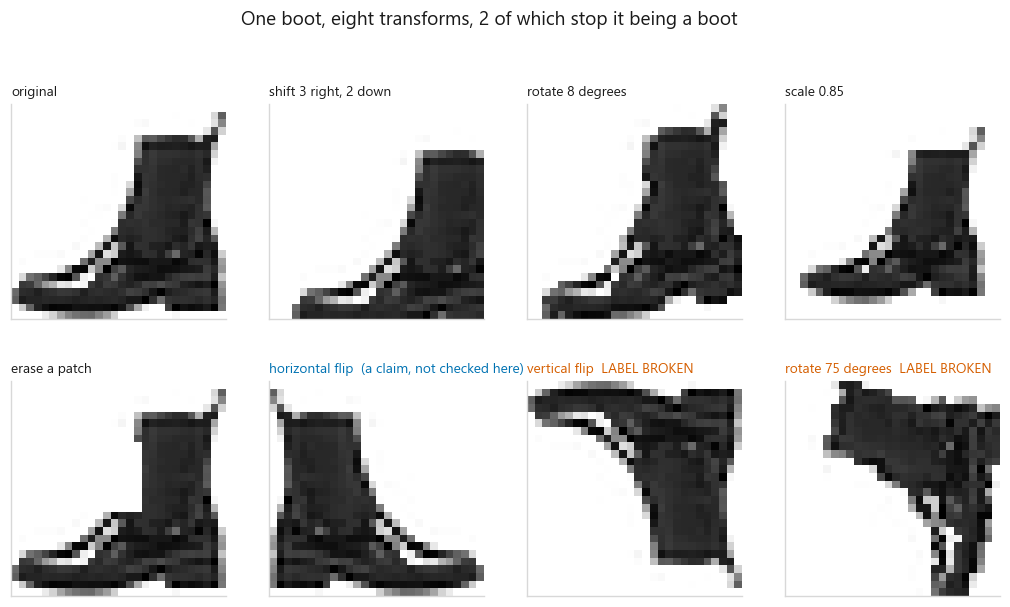

In [4]:
GALLERY = [
    ("original", lambda t: t, "kept"),
    ("shift 3 right, 2 down", lambda t: shift_batch(t.unsqueeze(0), 3, 2).squeeze(0), "kept"),
    ("rotate 8 degrees", lambda t: TF.rotate(t, 8.0), "kept"),
    ("scale 0.85", lambda t: TF.affine(t, angle=0.0, translate=[0, 0], scale=0.85,
                                       shear=[0.0, 0.0]), "kept"),
    ("erase a patch", lambda t: v2.functional.erase(t, 8, 8, 9, 9, torch.zeros(1, 1, 1)), "kept"),
    ("horizontal flip", lambda t: TF.hflip(t), "claimed"),
    ("vertical flip", lambda t: TF.vflip(t), "broken"),
    ("rotate 75 degrees", lambda t: TF.rotate(t, 75.0), "broken"),
]

index = 9        # a boot: it has a clear top, bottom, left and right
sample, sample_label = x_pool[index], int(y_pool[index])

fig, axes = plt.subplots(2, 4, figsize=(11.6, 6.0))
for ax, (name, transform, verdict) in zip(axes.ravel(), GALLERY):
    ax.imshow(transform(sample).squeeze(), cmap="gray_r", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    colour = {"kept": style.INK, "claimed": style.PALETTE[0], "broken": style.HIGHLIGHT}[verdict]
    mark = {"kept": "", "claimed": "  (a claim, not checked here)", "broken": "  LABEL BROKEN"}[verdict]
    ax.set_title(f"{name}{mark}", fontsize=9, color=colour, loc="left")

n_broken = sum(1 for _, _, v in GALLERY if v == "broken")
fig.suptitle(f"One {CLASSES[sample_label]}, eight transforms, "
             f"{n_broken} of which stop it being a {CLASSES[sample_label]}",
             x=0.5, y=1.01, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-transform-gallery.png")

print(f"image {index} of the pool, true class: {CLASSES[sample_label]}")
print("A 75 degree rotation and a vertical flip produce pictures that are not in "
      "Fashion-MNIST and not boots.")

Look at the bottom row rather than the top. Fashion-MNIST images are all upright
and roughly centred, photographed the same way. A vertical flip makes a boot that
hangs from the ceiling, which is not a picture of a boot and is certainly not a
picture from this dataset. A seventy-five degree rotation does the same thing
more gradually.

The horizontal flip is the interesting one, and it is labelled as a claim rather
than a fact on purpose. Mirroring a boot gives a boot, so the label survives. But
every shoe in Fashion-MNIST points the same way, so a mirrored one is a picture
the test set does not contain. Whether that helps or hurts is a question about
this dataset, not about flips, and I have not measured it here.

## 4. In practice, with torchvision

The standard arrangement is a transform object applied per image inside the
dataset, so every epoch sees a fresh draw. Two pipelines below: one that respects
the labels and one that does not.

In [5]:
SENSIBLE = v2.RandomAffine(degrees=8, translate=(0.10, 0.10), scale=(0.92, 1.08))

DESTRUCTIVE = v2.Compose([
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=75),
])


class Wrapped(Dataset):
    """Images and labels held in memory, with an optional per-image transform.

    The transform runs inside `__getitem__`, one image at a time. That is not a
    stylistic choice, and the cell below shows what the alternative does.
    """

    def __init__(self, images, labels, transform=None):
        self.images, self.labels, self.transform = images, labels, transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        image = self.images[i]
        if self.transform is not None:
            image = self.transform(image)
        return image, self.labels[i]


# The mistake, measured. A transform applied to a stacked batch draws its random
# parameters once and hands the same draw to every image in the batch.
torch.manual_seed(SEED)
repeated = sample.unsqueeze(0).repeat(6, 1, 1, 1)
in_one_call = SENSIBLE(repeated)
one_at_a_time = torch.stack([SENSIBLE(image) for image in repeated])

print("six copies of the same image, augmented two ways")
print(f"applied to the batch  : largest difference between copies "
      f"{float((in_one_call - in_one_call[0]).abs().max()):.4f}")
print(f"applied per image     : largest difference between copies "
      f"{float((one_at_a_time - one_at_a_time[0]).abs().max()):.4f}")
print("\nA zero in the first row means the batch got one shared transform, so the "
      "effective augmentation is a fraction of what you asked for.")

six copies of the same image, augmented two ways
applied to the batch  : largest difference between copies 0.0000
applied per image     : largest difference between copies 1.0000

A zero in the first row means the batch got one shared transform, so the effective augmentation is a fraction of what you asked for.


### The network and the training budget

The same small convolutional network as [08-02](../02-a-cnn-layer-by-layer/), so
nothing about the architecture is doing the work here.

Each run gets a fixed number of **gradient steps** rather than a fixed number of
epochs. That is the only way the sweep is fair: with fixed epochs, the 4,000-image
run would take sixteen times as many steps as the 250-image run, and I would be
measuring optimisation effort alongside data quantity.

In [6]:
class SmallCNN(nn.Module):
    """Two convolutional blocks and a small classifier. Copied from 08-02."""

    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_budget(images, labels, transform=None, steps=STEPS, seed=SEED):
    """Train for exactly `steps` gradient steps, cycling the data as often as needed."""
    torch.manual_seed(seed)
    model = SmallCNN().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(Wrapped(images, labels, transform), batch_size=BATCH, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))

    started, done = time.perf_counter(), 0
    while done < steps:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad(set_to_none=True)
            F.cross_entropy(model(xb), yb).backward()
            optimiser.step()
            done += 1
            if done >= steps:
                break
    return model, time.perf_counter() - started


@torch.no_grad()
def accuracy(model, images, labels, batch=1000):
    model.eval()
    correct = 0
    for start in range(0, len(labels), batch):
        logits = model(images[start:start + batch].to(device))
        correct += int((logits.argmax(1).cpu() == labels[start:start + batch]).sum())
    model.train()
    return correct / len(labels)


print(f"{sum(p.numel() for p in SmallCNN().parameters()):,} parameters, "
      f"{STEPS} gradient steps of {BATCH} images per run, "
      f"{STEPS * BATCH:,} image passes whatever the subset size")

105,866 parameters, 250 gradient steps of 128 images per run, 32,000 image passes whatever the subset size


## 5. When it wins and when it loses

Fifteen runs: five training set sizes, three augmentation policies, one seed.
Every run sees the same number of gradient steps and is scored on the same
10,000 test images.

In [7]:
CONDITIONS = [
    ("none", None),
    ("shift, rotate, scale", SENSIBLE),
    ("vertical flip, 75 degrees", DESTRUCTIVE),
]

started = time.perf_counter()
sweep_rows = []
for size in SIZES:
    for name, transform in CONDITIONS:
        model, seconds = train_budget(x_pool[:size], y_pool[:size], transform)
        score = accuracy(model, x_test, y_test)
        sweep_rows.append({"training images": size, "augmentation": name,
                           "test accuracy": score, "seconds": seconds})
        print(f"{size:>5} images, {name:<26} test {score:.4f}  ({seconds:.0f} s)")

sweep = pd.DataFrame(sweep_rows)
print(f"\nfifteen runs in {(time.perf_counter() - started) / 60:.1f} minutes on {device}")

  250 images, none                       test 0.7531  (2 s)


  250 images, shift, rotate, scale       test 0.7341  (23 s)


  250 images, vertical flip, 75 degrees  test 0.6305  (23 s)


  500 images, none                       test 0.7703  (2 s)


  500 images, shift, rotate, scale       test 0.7432  (24 s)


...

 2000 images, shift, rotate, scale       test 0.7591  (26 s)


 2000 images, vertical flip, 75 degrees  test 0.6457  (26 s)


 4000 images, none                       test 0.8117  (2 s)


 4000 images, shift, rotate, scale       test 0.7612  (25 s)


 4000 images, vertical flip, 75 degrees  test 0.6720  (24 s)

fifteen runs in 4.3 minutes on cuda


In [8]:
by_size = sweep.pivot(index="training images", columns="augmentation", values="test accuracy")
by_size = by_size[[name for name, _ in CONDITIONS]]

gain = by_size["shift, rotate, scale"] - by_size["none"]
damage = by_size["vertical flip, 75 degrees"] - by_size["none"]

print(by_size.to_string(float_format="{:.4f}".format))
print("\nchange in test accuracy against no augmentation")
print(pd.DataFrame({"sensible": gain, "label-destroying": damage})
      .to_string(float_format="{:+.4f}".format))

mean_accuracy = float(by_size.to_numpy().mean())
se = float(np.sqrt(mean_accuracy * (1 - mean_accuracy) / len(y_test)))
print(f"\nbinomial standard error at the sweep's mean accuracy of {mean_accuracy:.4f}, "
      f"over {len(y_test):,} test images: {se:.4f}")

small, large = min(SIZES), max(SIZES)
if gain.loc[small] > gain.loc[large] + se:
    verdict = (f"augmentation helped more at {small} images than at {large}, which is "
               f"what I expected")
elif gain.loc[large] > gain.loc[small] + se:
    verdict = (f"augmentation helped MORE at {large} images than at {small}, the opposite "
               f"of what I expected")
else:
    verdict = (f"the gain at {small} and at {large} images differ by less than one "
               f"standard error, so this sweep does not separate them")
print(f"\nverdict: {verdict}")
print(f"largest gain: {gain.max():+.4f} at {gain.idxmax():,} training images")
print(f"label-destroying augmentation cost between {damage.min():+.4f} and "
      f"{damage.max():+.4f} accuracy across the sweep")

augmentation      none  shift, rotate, scale  vertical flip, 75 degrees
training images                                                        
250             0.7531                0.7341                     0.6305
500             0.7703                0.7432                     0.6170
1000            0.8013                0.7655                     0.6606
2000            0.8092                0.7591                     0.6457
4000            0.8117                0.7612                     0.6720

change in test accuracy against no augmentation
                 sensible  label-destroying
training images                            
250               -0.0190           -0.1226
500               -0.0271           -0.1533
1000              -0.0358           -0.1407
2000              -0.0501           -0.1635
4000              -0.0505           -0.1397

binomial standard error at the sweep's mean accuracy of 0.7290, over 10,000 test images: 0.0044

verdict: augmentation helped more at 250 

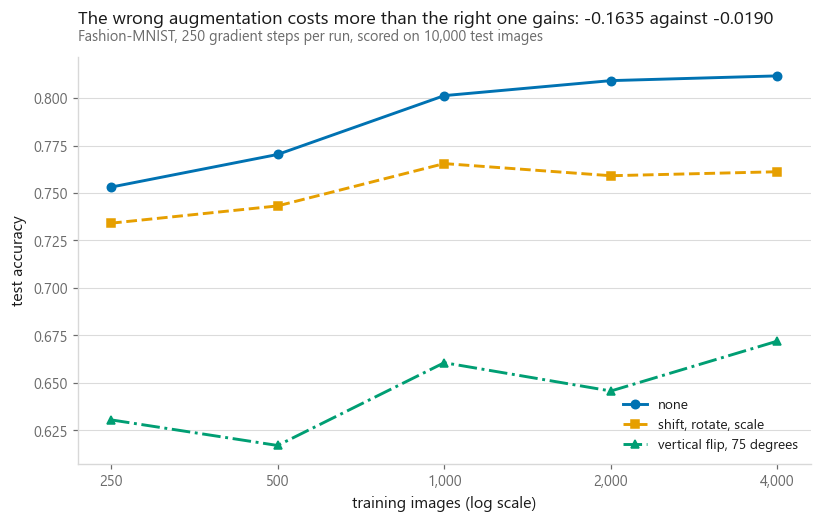

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 4.8))
for i, (name, _) in enumerate(CONDITIONS):
    ax.plot(by_size.index, by_size[name], color=style.PALETTE[i], ls=style.DASHES[i],
            marker=style.MARKERS[i], label=name)

ax.set_xscale("log")
ax.minorticks_off()
ax.set_xticks(SIZES, [f"{s:,}" for s in SIZES])
ax.set_xlabel("training images (log scale)")
ax.set_ylabel("test accuracy")
ax.legend(loc="lower right", fontsize=9)
style.title(
    ax,
    f"The wrong augmentation costs more than the right one gains: "
    f"{damage.min():+.4f} against {gain.max():+.4f}",
    f"Fashion-MNIST, {STEPS} gradient steps per run, scored on {len(y_test):,} test images")
style.save(fig, FIG / "fig-02-accuracy-by-training-size.png")

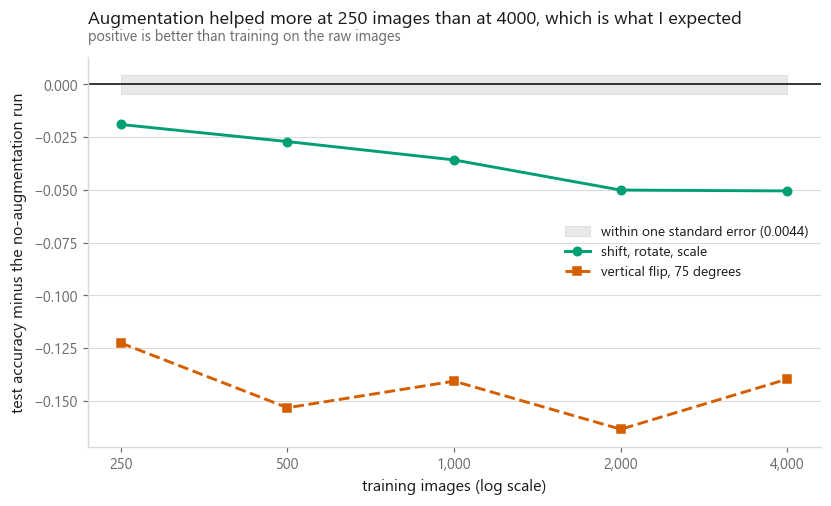

In [10]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.axhline(0, color=style.INK, lw=1.1)
ax.fill_between(by_size.index, -se, se, color=style.NEUTRAL, alpha=0.28,
                label=f"within one standard error ({se:.4f})")
ax.plot(by_size.index, gain, color=style.PALETTE[2], ls=style.DASHES[0],
        marker=style.MARKERS[0], label="shift, rotate, scale")
ax.plot(by_size.index, damage, color=style.HIGHLIGHT, ls=style.DASHES[1],
        marker=style.MARKERS[1], label="vertical flip, 75 degrees")

ax.set_xscale("log")
ax.minorticks_off()
ax.set_xticks(SIZES, [f"{s:,}" for s in SIZES])
ax.set_xlabel("training images (log scale)")
ax.set_ylabel("test accuracy minus the no-augmentation run")
ax.legend(loc="best", fontsize=9)
style.title(ax, verdict[0].upper() + verdict[1:],
            "positive is better than training on the raw images")
style.save(fig, FIG / "fig-03-gain-against-baseline.png")

### What the label-destroying run is actually doing

It is worth being precise about the failure, because "augmentation hurt" is not
the mechanism. Half the images fed to that model are upside down and most of the
rest are heavily rotated, all still carrying their original labels. The model is
being asked to learn that orientation carries no information about the class.
It obliges. Then it is tested on images that are all upright, where orientation
carried a great deal of information, and it has thrown that away.

Nothing in the training loop can detect this. The loss goes down, the training
accuracy goes up, and the augmented training set is internally consistent. Only
the test set knows, and only because the test set was left alone.

### What it costs per epoch

In [11]:
def one_epoch_seconds(images, labels, transform, repeats=2):
    """Seconds for one pass over the data, including whatever the pipeline does to it."""
    model = SmallCNN().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(Wrapped(images, labels, transform), batch_size=BATCH, shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))
    times = []
    for _ in range(repeats):
        started = time.perf_counter()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad(set_to_none=True)
            F.cross_entropy(model(xb), yb).backward()
            optimiser.step()
        times.append(time.perf_counter() - started)
    return float(np.mean(times))


def random_shift_batch(images, max_pixels, generator):
    """Per-image random translation for a whole batch, in one grid sample.

    The offsets are drawn per image, so this is not the batch-level mistake from
    section 4: it is the same augmentation, vectorised. Integer pixel offsets land
    exactly on pixel centres, so the interpolation returns the original values.
    """
    n, _, height, width = images.shape
    dx = torch.randint(-max_pixels, max_pixels + 1, (n,), generator=generator).float()
    dy = torch.randint(-max_pixels, max_pixels + 1, (n,), generator=generator).float()
    theta = torch.zeros(n, 2, 3)
    theta[:, 0, 0] = 1.0
    theta[:, 1, 1] = 1.0
    # grid_sample maps output positions back to input positions, hence the sign
    theta[:, 0, 2] = -2.0 * dx / width
    theta[:, 1, 2] = -2.0 * dy / height
    grid = F.affine_grid(theta.to(images.device), images.shape, align_corners=False)
    return F.grid_sample(images, grid, align_corners=False, padding_mode="zeros")


# the vectorised version, timed the same way
def one_epoch_seconds_vectorised(images, labels, max_pixels=3, repeats=2):
    model = SmallCNN().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR)
    generator = torch.Generator().manual_seed(SEED)
    times = []
    for _ in range(repeats):
        started = time.perf_counter()
        order = torch.randperm(len(labels), generator=generator)
        for start in range(0, len(labels), BATCH):
            picks = order[start:start + BATCH]
            xb = random_shift_batch(images[picks], max_pixels, generator).to(device)
            yb = labels[picks].to(device)
            optimiser.zero_grad(set_to_none=True)
            F.cross_entropy(model(xb), yb).backward()
            optimiser.step()
        times.append(time.perf_counter() - started)
    return float(np.mean(times))


cost = pd.DataFrame([
    {"pipeline": "no augmentation",
     "seconds per epoch": one_epoch_seconds(x_pool, y_pool, None)},
    {"pipeline": "torchvision, per image",
     "seconds per epoch": one_epoch_seconds(x_pool, y_pool, SENSIBLE)},
    {"pipeline": "shift only, vectorised",
     "seconds per epoch": one_epoch_seconds_vectorised(x_pool, y_pool)},
])
cost["times the baseline"] = cost["seconds per epoch"] / cost["seconds per epoch"].iloc[0]

print(f"one epoch over {len(y_pool):,} images, averaged over two passes, on {device}")
print(cost.to_string(index=False, float_format="{:.3f}".format))

one epoch over 4,000 images, averaged over two passes, on cuda
              pipeline  seconds per epoch  times the baseline
       no augmentation              0.226               1.000
torchvision, per image              2.710              11.986
shift only, vectorised              0.256               1.133


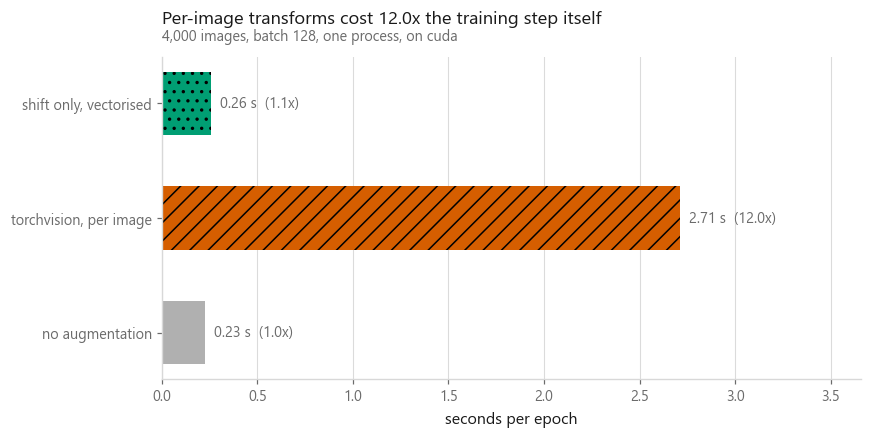

In [12]:
fig, ax = plt.subplots(figsize=(8.2, 3.8))
colours = [style.NEUTRAL, style.HIGHLIGHT, style.PALETTE[2]]
bars = ax.barh(cost["pipeline"], cost["seconds per epoch"], color=colours, height=0.55)
for bar, hatch in zip(bars, ["", "//", ".."]):
    bar.set_hatch(hatch)
for bar, value, ratio in zip(bars, cost["seconds per epoch"], cost["times the baseline"]):
    ax.annotate(f"{value:.2f} s  ({ratio:.1f}x)",
                xy=(value, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9.5, color=style.MUTED)

ax.set_xlabel("seconds per epoch")
ax.set_xlim(0, cost["seconds per epoch"].max() * 1.35)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(
    ax,
    f"Per-image transforms cost {cost['times the baseline'].iloc[1]:.1f}x the "
    f"training step itself",
    f"{len(y_pool):,} images, batch {BATCH}, one process, on {device}")
style.save(fig, FIG / "fig-04-seconds-per-epoch.png")

The augmentation is arithmetic on images and the model here is small, so the
transform can easily cost more than the gradient step it feeds. That ratio is a
property of this pairing rather than a law: put a large network on the other end
and the same transforms disappear into the noise. What does generalise is the
fix. Doing the work per image in Python is what costs; the same translation
applied to a whole batch as one tensor operation is in the third row.

### Test-time augmentation

If the model is supposed to be invariant to small shifts, you can ask it several
times and average. Five views per test image here: the original and four
two-pixel shifts, using the hand-written shift from section 3 so the views are
deterministic and reproducible.

In [13]:
best_model, _ = train_budget(x_pool, y_pool, SENSIBLE)

VIEWS = [(0, 0), (2, 0), (-2, 0), (0, 2), (0, -2)]


@torch.no_grad()
def tta_accuracy(model, images, labels, views, batch=1000):
    """Average the softmax over several fixed views of each test image."""
    model.eval()
    correct = 0
    for start in range(0, len(labels), batch):
        chunk = images[start:start + batch]
        probs = torch.zeros(len(chunk), 10)
        for dx, dy in views:
            shifted = shift_batch(chunk, dx, dy).to(device)
            probs += F.softmax(model(shifted), dim=1).cpu()
        correct += int(((probs / len(views)).argmax(1) == labels[start:start + batch]).sum())
    model.train()
    return correct / len(labels)


single = accuracy(best_model, x_test, y_test)
tta_rows = []
for k in range(1, len(VIEWS) + 1):
    tta_rows.append({"views averaged": k,
                     "test accuracy": tta_accuracy(best_model, x_test, y_test, VIEWS[:k]),
                     "forward passes": k * len(y_test)})

tta = pd.DataFrame(tta_rows)
tta["change against one view"] = tta["test accuracy"] - single
print(tta.to_string(index=False, formatters={
    "test accuracy": "{:.4f}".format,
    "forward passes": "{:,}".format,
    "change against one view": "{:+.4f}".format,
}))

best_k = int(tta.loc[tta["test accuracy"].idxmax(), "views averaged"])
best_tta = float(tta["test accuracy"].max())
if best_tta > single + se:
    tta_verdict = (f"averaging {best_k} views beat the single view by "
                   f"{best_tta - single:+.4f}, more than one standard error")
elif best_tta > single:
    tta_verdict = (f"averaging views gained {best_tta - single:+.4f}, which is inside "
                   f"one standard error, so this run does not establish it")
else:
    tta_verdict = "averaging views did not beat the single forward pass at all here"
print(f"\nverdict: {tta_verdict}")

 views averaged test accuracy forward passes change against one view
              1        0.7612         10,000                 +0.0000
              2        0.7607         20,000                 -0.0005
              3        0.7618         30,000                 +0.0006
              4        0.7634         40,000                 +0.0022
              5        0.7622         50,000                 +0.0010

verdict: averaging views gained +0.0022, which is inside one standard error, so this run does not establish it


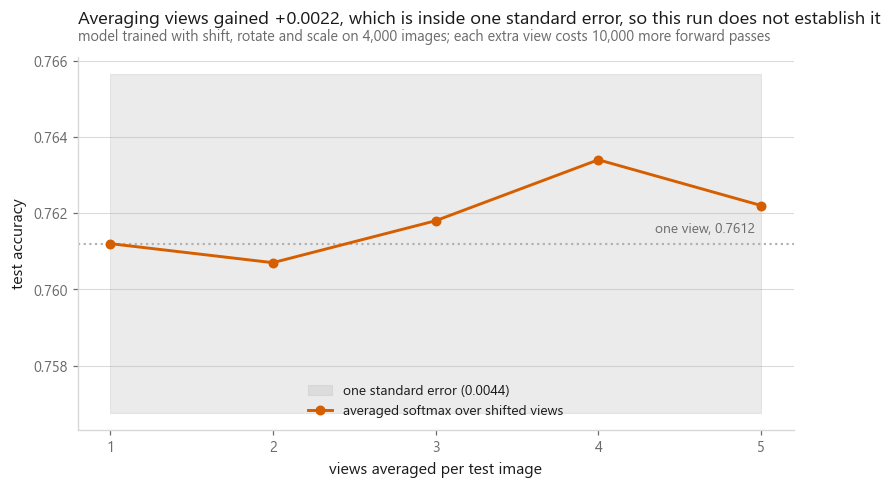

In [14]:
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.axhline(single, color=style.NEUTRAL, ls=":", lw=1.4)
ax.annotate(f"one view, {single:.4f}", xy=(len(VIEWS), single), xytext=(-4, 7),
            textcoords="offset points", ha="right", fontsize=9, color=style.MUTED)
ax.fill_between([1, len(VIEWS)], single - se, single + se, color=style.NEUTRAL, alpha=0.25,
                label=f"one standard error ({se:.4f})")
ax.plot(tta["views averaged"], tta["test accuracy"], color=style.HIGHLIGHT,
        marker=style.MARKERS[0], label="averaged softmax over shifted views")

ax.set_xticks(tta["views averaged"])
ax.set_xlabel("views averaged per test image")
ax.set_ylabel("test accuracy")
ax.legend(loc="best", fontsize=9)
style.title(ax, tta_verdict[0].upper() + tta_verdict[1:],
            f"model trained with shift, rotate and scale on {len(y_pool):,} images; "
            f"each extra view costs {len(y_test):,} more forward passes")
style.save(fig, FIG / "fig-05-test-time-augmentation.png")

Test-time augmentation is the cheapest experiment in this notebook and the one
with the worst ratio of attention to payoff in the wild. It multiplies inference
cost by the number of views, and it can only recover accuracy that the model
loses to variation it was already trained to ignore. Read the printed verdict
above against the standard error rather than against zero.

In [15]:
print(f"whole notebook: {(time.perf_counter() - NOTEBOOK_STARTED) / 60:.1f} minutes on {device}")

whole notebook: 4.7 minutes on cuda


## Cheat sheet

| | |
|---|---|
| **What it is** | Random label-preserving transformations applied to training inputs, fresh every epoch |
| **Use it when** | Data is scarce relative to model capacity, and you can name an invariance the labels genuinely have |
| **Skip it when** | You have plenty of data, or you cannot name the invariance. Then it is cost without information |
| **The rule** | Every transform is a claim that the label survives it. Nothing in training checks that claim |
| **Fashion-MNIST** | Small shifts, small rotations, small scale changes. Not vertical flips, not large rotations |
| **The usual bug** | Applying a transform to a batch instead of per image. One draw for the whole batch, measured in section 4 |
| **The other usual bug** | Augmenting the validation or test set. Then you cannot see the damage you are doing |
| **Cost** | Per-image transforms in Python can outweigh the gradient step on a small model. Vectorise or use workers |
| **Test time** | Averaging predictions over several views multiplies inference cost. Measure before shipping it |

## What to remember

1. An augmentation encodes an invariance you claim the label has. If the claim is
   false you are training on wrong labels, and the loss curve will not tell you.
2. The sweep in section 5 measures the payoff against training set size, and the
   printed verdict says whether it faded as data grew.
3. The label-destroying pipeline was not a subtle mistake: half the images were
   upside down. The printed damage column is what that cost.
4. Augmentation adds no information. It spends model capacity on the variation
   you care about instead of variation you have decided to ignore.
5. A transform applied to a stacked batch gives every image in that batch the
   same random draw. Section 4 prints the difference between copies as zero.
6. Augmentation is not free. Section 5 has the seconds per epoch and the ratio
   against a plain pass, on this machine and this model.
7. Test-time augmentation multiplies inference cost by the number of views. Judge
   the gain against the standard error, which is printed beside it.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-05 Transfer learning and fine-tuning](../05-transfer-learning/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#DataAugmentation` `#ComputerVision` `#PyTorch` `#torchvision`
`#FashionMNIST` `#MachineLearning` `#Python` `#MLTutorial` `#AI`